# Data Analysis 

This notebook is to check whether any additional preprocessing is needed for the data outputted directly from the data pipeline from the Alberta Historical Wildfires Dataset.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
ROOT = Path("..").resolve()
DATASETS = {
    "train": ROOT / "data/static/v1/scenario_parameter_records_seeded_train.json",
    "val": ROOT / "data/static/v1/scenario_parameter_records_seeded_val.json",
    "holdout": ROOT / "data/static/v1/scenario_parameter_records_seeded_holdout.json",
}
NUMERIC_COLUMNS = [
    "base_spread_prob",
    "wind_strength",
    "spread_rate_1h_m",
    "spread_score",
    "weather_score",
    "cffdrs_dryness_score",
    "size_factor",
    "fire_type_factor",
    "fuel_factor",
    "rain_factor",
]

In [2]:
def load_records(path: Path, split_name: str) -> pd.DataFrame:
    payload = json.loads(path.read_text())
    records = payload.get("records", []) if isinstance(payload, dict) else payload
    frame = pd.DataFrame(records)
    frame["split_source"] = split_name
    return frame

frames = [load_records(path, split) for split, path in DATASETS.items()]
df = pd.concat(frames, ignore_index=True)
df.head()

,record_id,fire_id,source,province,year,split,base_spread_prob,severity_bucket,wind_direction,wind_strength,spread_rate_1h_m,spread_score,weather_score,cffdrs_dryness_score,size_factor,fire_type_factor,fuel_factor,rain_factor,observed_spread_rate_m_min,assessment_hectares,fire_type,fuel_type,record_quality_flag,ignition_seed,layout_seed,split_source
0,AB-2008-MWF074__20080703,AB-2008-MWF074,AB_HISTORICAL_WILDFIRE,AB,2008,train,0.1792,high,S,0.1625,6000.0,0.7736,0.4535,0.0,0.9500,1.00,1.12,1.0,100.0,0.50,surface,C2,measured,14443855870861270751,1.127873e+19,train
1,AB-2018-SWF158__20180901,AB-2018-SWF158,AB_HISTORICAL_WILDFIRE,AB,2018,train,0.1571,medium,NW,0.1625,4260.0,0.6504,0.2518,0.0,0.9500,1.00,1.00,1.0,71.0,0.01,surface,O1b,measured,10198127025334700556,1.445778e+19,train
2,AB-2012-MWF047__20120710,AB-2012-MWF047,AB_HISTORICAL_WILDFIRE,AB,2012,train,0.1797,high,W,0.1625,4200.0,0.7759,0.4640,0.0,0.9500,1.00,1.12,1.0,70.0,0.30,surface,C2,measured,8000671072565187824,8.493056e+17,train
3,AB-2014-GWF044__20140715,AB-2014-GWF044,AB_HISTORICAL_WILDFIRE,AB,2014,train,0.2200,high,SW,0.2625,3900.0,1.0000,0.5501,0.0,1.0250,1.18,1.12,1.0,65.0,1000.00,crown,C3,measured,15167517599069789484,1.618321e+19,train
4,AB-2017-CWF254__20171017,AB-2017-CWF254,AB_HISTORICAL_WILDFIRE,AB,2017,train,0.2194,high,W,0.6000,3600.0,0.9966,0.7679,0.0,0.9507,1.18,1.12,1.0,60.0,10.00,crown,C3,measured,2787351251254423658,1.730736e+19,train


In [3]:
summary = {
    "rows_total": int(len(df)),
    "rows_by_split_source": df["split_source"].value_counts(dropna=False).to_dict(),
    "rows_by_split_field": df["split"].value_counts(dropna=False).to_dict(),
    "unique_record_id": int(df["record_id"].nunique(dropna=True)),
    "duplicate_record_id_count": int(df.duplicated(subset=["record_id"]).sum()),
    "duplicate_fire_id_count": int(df.duplicated(subset=["fire_id"]).sum()),
}
summary

{'rows_total': 19246,
 'rows_by_split_source': {'train': 18252, 'val': 993, 'holdout': 1},
 'rows_by_split_field': {'train': 18252, 'val': 993, 'holdout': 1},
 'unique_record_id': 19246,
 'duplicate_record_id_count': 0,
 'duplicate_fire_id_count': 0}

In [4]:
required = [
    "record_id",
    "split",
    "base_spread_prob",
    "severity_bucket",
    "wind_direction",
    "wind_strength",
    "ignition_seed",
    "layout_seed",
]
null_counts = df[required].isna().sum().sort_values(ascending=False)
null_counts

record_id           0
split               0
base_spread_prob    0
severity_bucket     0
wind_direction      0
wind_strength       0
ignition_seed       0
layout_seed         0
dtype: int64

In [12]:
print("All columns:")
print(df.columns.tolist())

const_cols = []
for col in valid_numeric_cols:
    unique_vals = df[col].nunique()
    if unique_vals <= 1:
        print(f"Constant column: {col}")
        const_cols.append(col)

print("\nNumeric cols:")
valid_numeric_cols = [col for col in NUMERIC_COLUMNS if col in df.columns and col not in const_cols]
print(valid_numeric_cols)

All columns:
['record_id', 'fire_id', 'source', 'province', 'year', 'split', 'base_spread_prob', 'severity_bucket', 'wind_direction', 'wind_strength', 'spread_rate_1h_m', 'spread_score', 'weather_score', 'cffdrs_dryness_score', 'size_factor', 'fire_type_factor', 'fuel_factor', 'rain_factor', 'observed_spread_rate_m_min', 'assessment_hectares', 'fire_type', 'fuel_type', 'record_quality_flag', 'ignition_seed', 'layout_seed', 'split_source']
⚠️ Constant column: cffdrs_dryness_score

Numeric cols:
['base_spread_prob', 'wind_strength', 'spread_rate_1h_m', 'spread_score', 'weather_score', 'size_factor', 'fire_type_factor', 'fuel_factor', 'rain_factor']


# `cffdrs_dryness_score` needs to be dropped because it is constant.

This is from a data pipeline config, where if the ingestion is run without the `cffdrs-year` flag, the column defaults to 0.

In [36]:
def kde_is_safe(series, min_points=5):
    """
    Check whether KDE is safe for a single numeric series.
    """
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) < min_points:
        return False, f"fewer than {min_points} valid points"
    if s.nunique() <= 1:
        return False, "constant or single unique value"
    if np.isclose(s.var(), 0):
        return False, "zero or near-zero variance"

    return True, "ok"


def kde_is_safe_by_group(df, col, group_col="split_source", min_points=5):
    """
    KDE is only safe if every remaining group used by hue has enough variation.
    """
    temp = df[[col, group_col]].replace([np.inf, -np.inf], np.nan).dropna(subset=[col, group_col])

    if temp.empty:
        return False, "no valid data after cleaning"

    for group_name, group_df in temp.groupby(group_col):
        ok, reason = kde_is_safe(group_df[col], min_points=min_points)
        if not ok:
            return False, f"group '{group_name}' failed: {reason}"

    return True, "ok"


def plot_numeric_column(
    df,
    col,
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=None,
    log_x=False,
    bins=30,
    exclude_groups_from_density=("holdout",),
):
    """
    Plot histogram + boxplot for one column.

    Behavior:
    - Groups in exclude_groups_from_density are excluded from histogram density + KDE.
    - Those excluded groups are shown as vertical line(s) on the histogram.
    - Those excluded groups are shown as point(s) on the boxplot.

    Returns a dict with KDE status info.
    """
    if col not in df.columns:
        return {"column": col, "kde_used": False, "status": "missing column"}

    temp = df[[col, group_col]].copy() if group_col in df.columns else df[[col]].copy()
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna(subset=[col])

    if temp.empty:
        return {"column": col, "kde_used": False, "status": "no valid numeric data"}

    plot_df = temp.copy()

    # Clipping for easier viewing
    if clip_percentiles is not None:
        low_q, high_q = clip_percentiles
        low = plot_df[col].quantile(low_q)
        high = plot_df[col].quantile(high_q)
        plot_df[col] = plot_df[col].clip(lower=low, upper=high)

    # Log transform for positive skewed data
    title_suffix = ""
    if log_x:
        positive_mask = plot_df[col] > 0
        plot_df = plot_df.loc[positive_mask].copy()
        if plot_df.empty:
            return {"column": col, "kde_used": False, "status": "log_x requested but no positive values"}
        plot_df[col] = np.log10(plot_df[col])
        title_suffix = " (log10 scale)"

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    kde_ok = False
    kde_reason = "kde not evaluated"
    excluded_summary = []

    if group_col in plot_df.columns:
        excluded_groups_from_density = set(exclude_groups_from_density)

        density_df = plot_df.loc[~plot_df[group_col].isin(excluded_groups_from_density)].copy()
        marker_df = plot_df.loc[plot_df[group_col].isin(excluded_groups_from_density)].copy()

        # Decide KDE safety using only density groups
        if density_df.empty:
            kde_ok = False
            kde_reason = "no groups left after excluding marker-only groups"
        else:
            kde_ok, kde_reason = kde_is_safe_by_group(
                density_df, col, group_col=group_col, min_points=min_points_for_kde
            )

        # Histogram / KDE for train/val/etc. only
        try:
            if not density_df.empty:
                sns.histplot(
                    data=density_df,
                    x=col,
                    hue=group_col,
                    kde=kde_ok,
                    bins=bins,
                    stat="density",
                    common_norm=False,
                    ax=ax[0]
                )
            else:
                sns.histplot(
                    data=plot_df,
                    x=col,
                    kde=False,
                    bins=bins,
                    stat="density",
                    ax=ax[0]
                )
        except Exception as e:
            kde_ok = False
            kde_reason = f"histplot/KDE runtime failure: {e}"

            if not density_df.empty:
                sns.histplot(
                    data=density_df,
                    x=col,
                    hue=group_col,
                    kde=False,
                    bins=bins,
                    stat="density",
                    common_norm=False,
                    ax=ax[0]
                )
            else:
                sns.histplot(
                    data=plot_df,
                    x=col,
                    kde=False,
                    bins=bins,
                    stat="density",
                    ax=ax[0]
                )

        # Show excluded groups as vertical line(s)
        if not marker_df.empty:
            for group_name, group_data in marker_df.groupby(group_col):
                vals = group_data[col].tolist()
                excluded_summary.append(f"{group_name}: n={len(vals)}, values={np.round(vals, 4).tolist()}")

                for v in vals:
                    ax[0].axvline(v, linestyle="--", alpha=0.9)

        if excluded_summary:
            ax[0].text(
                0.99, 0.98,
                "Marker-only groups:\n" + "\n".join(excluded_summary),
                transform=ax[0].transAxes,
                ha="right", va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
            )

        # Boxplot for density groups, points for excluded groups
        order = []
        if not density_df.empty:
            order.extend(list(pd.unique(density_df[group_col])))
        if not marker_df.empty:
            for g in pd.unique(marker_df[group_col]):
                if g not in order:
                    order.append(g)

        if not density_df.empty:
            sns.boxplot(
                data=density_df,
                x=group_col,
                y=col,
                order=order,
                ax=ax[1]
            )

        if not marker_df.empty:
            sns.stripplot(
                data=marker_df,
                x=group_col,
                y=col,
                order=order,
                jitter=False,
                size=8,
                marker="D",
                color="black",
                ax=ax[1]
            )

    else:
        # No grouping column
        kde_ok, kde_reason = kde_is_safe(plot_df[col], min_points=min_points_for_kde)

        try:
            sns.histplot(
                data=plot_df,
                x=col,
                kde=kde_ok,
                bins=bins,
                stat="density",
                ax=ax[0]
            )
        except Exception as e:
            kde_ok = False
            kde_reason = f"histplot/KDE runtime failure: {e}"
            sns.histplot(
                data=plot_df,
                x=col,
                kde=False,
                bins=bins,
                stat="density",
                ax=ax[0]
            )

        sns.boxplot(data=plot_df, y=col, ax=ax[1])

    ax[0].set_title(f"Distribution: {col}{title_suffix}")
    ax[1].set_title(f"Boxplot: {col}{title_suffix}")

    plt.tight_layout()
    plt.show()

    status = kde_reason
    if group_col in plot_df.columns and exclude_groups_from_density:
        status += f" | excluded from density/KDE: {list(exclude_groups_from_density)}"

    return {
        "column": col,
        "kde_used": kde_ok,
        "status": status
    }

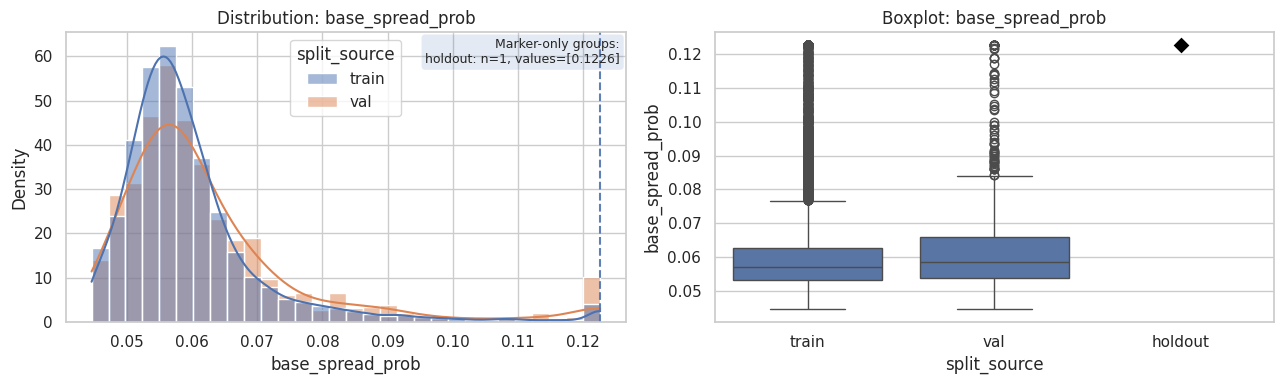

{'column': 'base_spread_prob',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [37]:
plot_numeric_column(
    df,
    'base_spread_prob',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

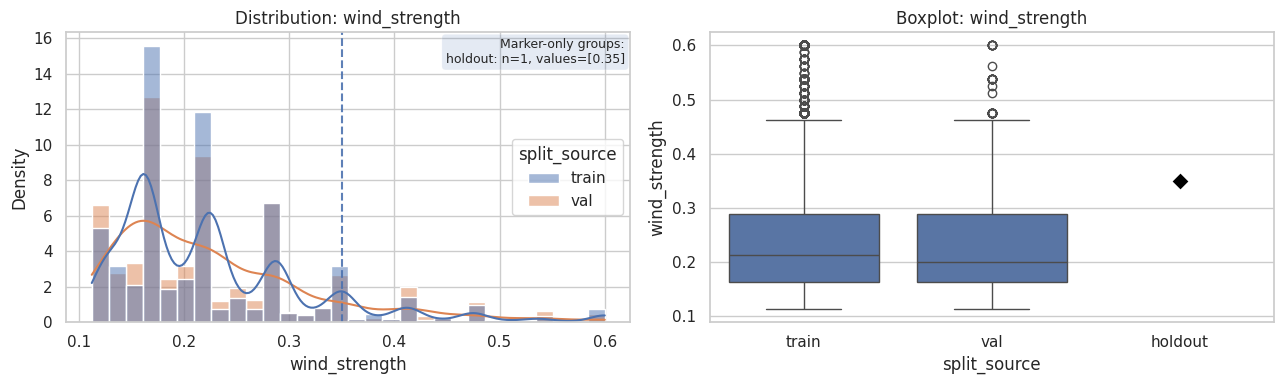

{'column': 'wind_strength',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [38]:
plot_numeric_column(
    df,
    'wind_strength',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

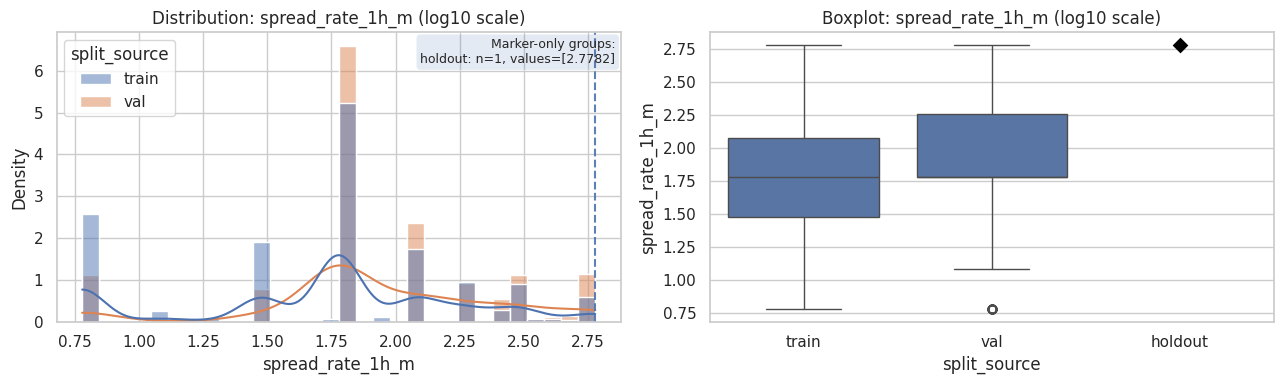

{'column': 'spread_rate_1h_m',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [50]:
plot_numeric_column(
    df,
    'spread_rate_1h_m',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=True,
    exclude_groups_from_density=("holdout",)
)

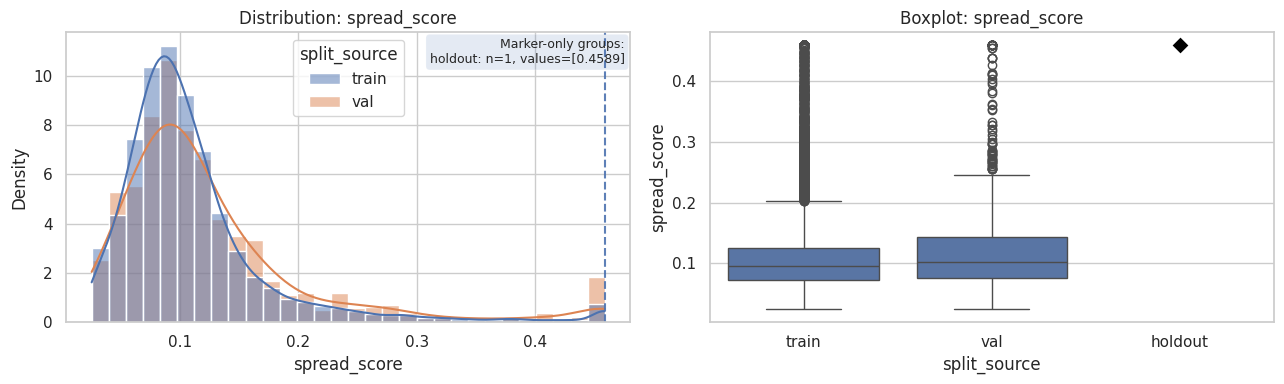

{'column': 'spread_score',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [40]:
plot_numeric_column(
    df,
    'spread_score',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

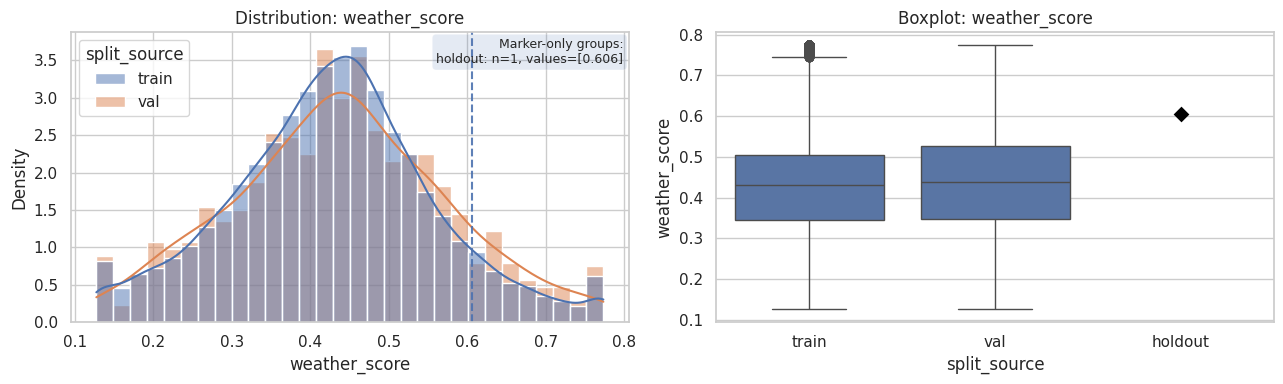

{'column': 'weather_score',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [41]:
plot_numeric_column(
    df,
    'weather_score',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

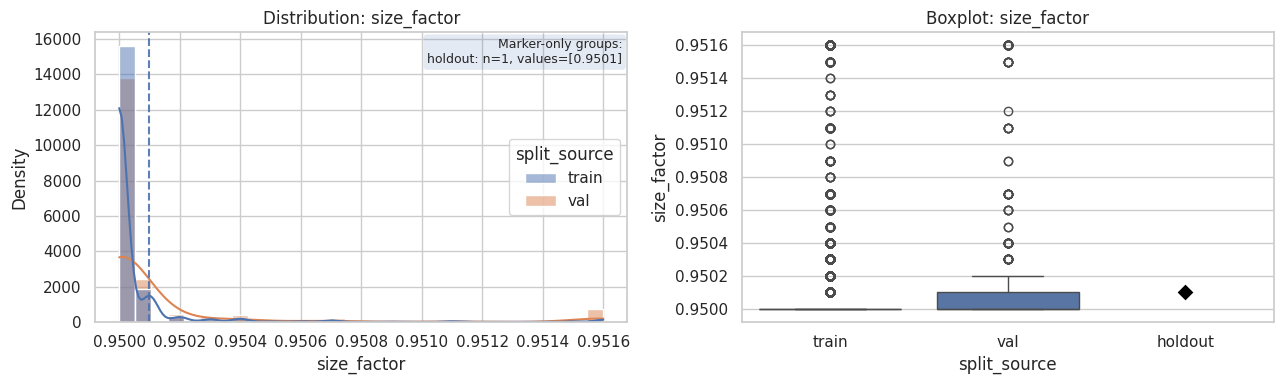

{'column': 'size_factor',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [42]:
plot_numeric_column(
    df,
    'size_factor',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

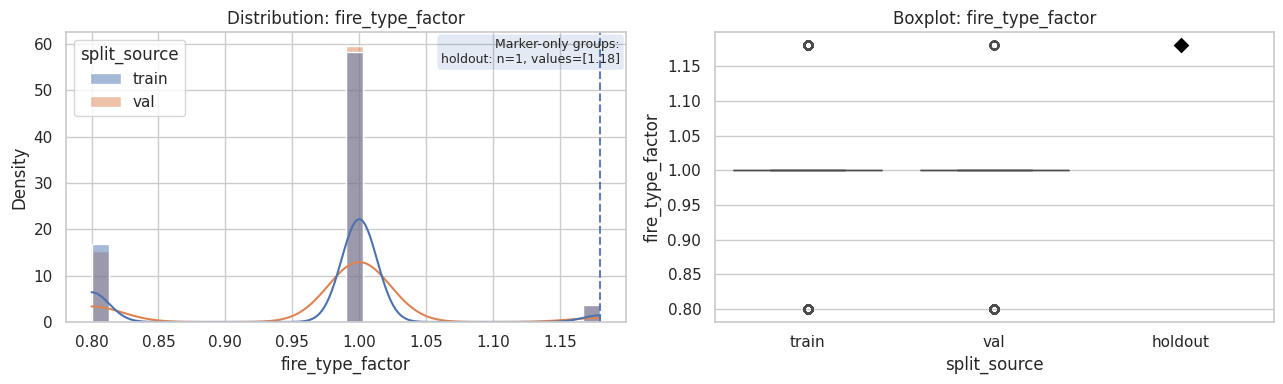

{'column': 'fire_type_factor',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [43]:
plot_numeric_column(
    df,
    'fire_type_factor',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

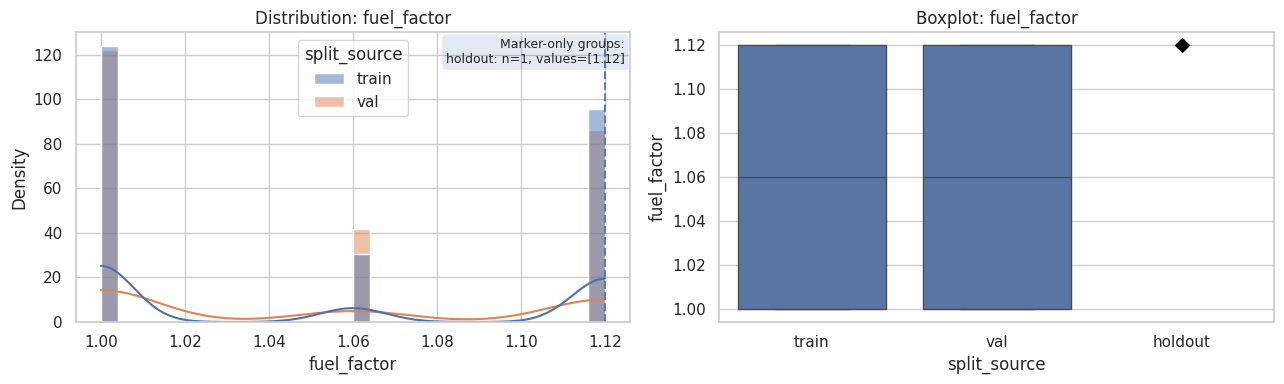

{'column': 'fuel_factor',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [44]:
plot_numeric_column(
    df,
    'fuel_factor',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

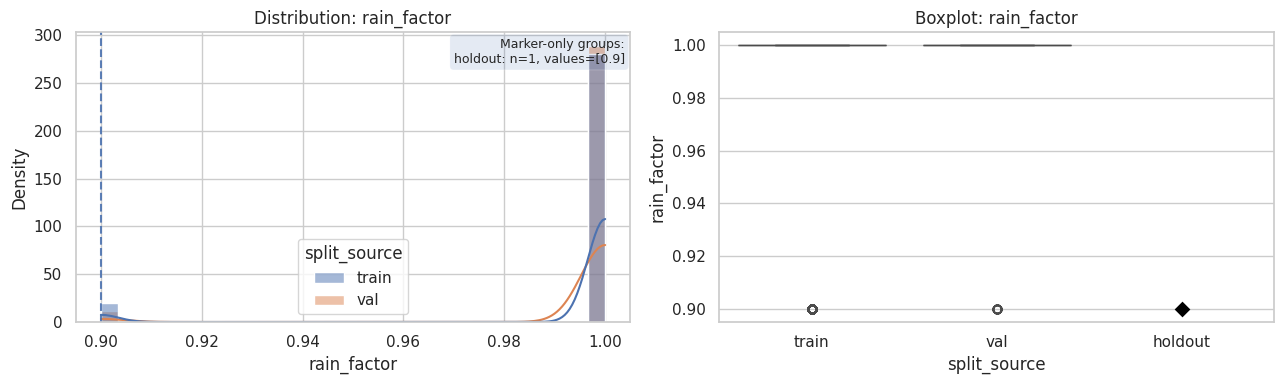

{'column': 'rain_factor',
 'kde_used': True,
 'status': "ok | excluded from density/KDE: ['holdout']"}

In [45]:
plot_numeric_column(
    df,
    'rain_factor',
    group_col="split_source",
    min_points_for_kde=5,
    clip_percentiles=(0.01, 0.99),
    log_x=False
)

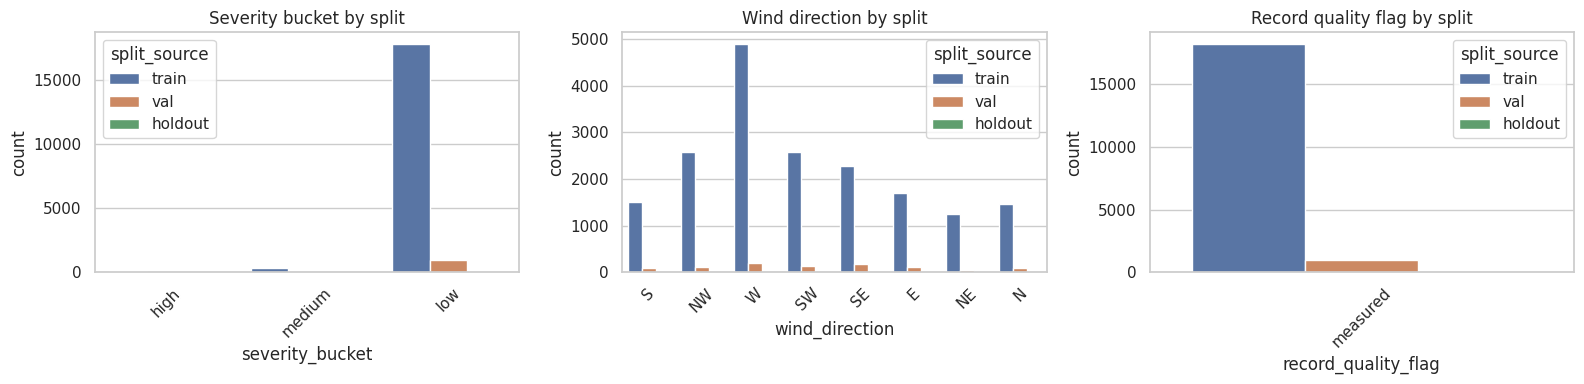

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="severity_bucket", hue="split_source", ax=axes[0])
axes[0].set_title("Severity bucket by split")
sns.countplot(data=df, x="wind_direction", hue="split_source", ax=axes[1])
axes[1].set_title("Wind direction by split")
sns.countplot(data=df, x="record_quality_flag", hue="split_source", ax=axes[2])
axes[2].set_title("Record quality flag by split")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [47]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or np.isnan(iqr):
        return pd.Series(False, index=series.index)
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return (series < lo) | (series > hi)

outlier_flags = pd.DataFrame(index=df.index)
for col in NUMERIC_COLUMNS:
    if col in df.columns:
        outlier_flags[col] = iqr_outlier_mask(pd.to_numeric(df[col], errors="coerce"))

df_outliers = df[outlier_flags.any(axis=1)].copy()
df_outliers["outlier_feature_count"] = outlier_flags.sum(axis=1)
outlier_summary = outlier_flags.sum().sort_values(ascending=False)
outlier_summary

spread_rate_1h_m        1926
base_spread_prob        1372
spread_score            1366
wind_strength            728
weather_score            367
cffdrs_dryness_score       0
size_factor                0
fire_type_factor           0
fuel_factor                0
rain_factor                0
dtype: int64

In [48]:
cols = ["record_id", "fire_id", "split", "split_source", "severity_bucket", "wind_direction", "outlier_feature_count"]
numeric_present = [c for c in NUMERIC_COLUMNS if c in df_outliers.columns]
display(df_outliers[cols + numeric_present].sort_values("outlier_feature_count", ascending=False).head(50))

,record_id,fire_id,split,split_source,severity_bucket,wind_direction,outlier_feature_count,base_spread_prob,wind_strength,spread_rate_1h_m,spread_score,weather_score,cffdrs_dryness_score,size_factor,fire_type_factor,fuel_factor,rain_factor
532,AB-2013-LWF127__20130819,AB-2013-LWF127,train,train,low,W,5,0.0962,0.6000,300.0,0.3121,0.7908,0.0,0.9507,1.00,1.12,1.0
215,AB-2011-SWF065__20110514,AB-2011-SWF065,train,train,medium,SE,5,0.1400,0.6000,600.0,0.5557,0.9010,0.0,0.9504,1.18,1.12,1.0
539,AB-2006-MWF070__20060627,AB-2006-MWF070,train,train,medium,SW,5,0.1077,0.5125,300.0,0.3763,0.8211,0.0,0.9507,1.18,1.12,1.0
1169,AB-2011-SWF052__20110514,AB-2011-SWF052,train,train,low,SE,5,0.0904,0.6000,240.0,0.2798,0.8399,0.0,0.9500,1.00,1.06,1.0
573,AB-2018-CWF006__20180428,AB-2018-CWF006,train,train,low,E,5,0.0984,0.6000,300.0,0.3243,0.8466,0.0,0.9504,1.00,1.12,1.0
579,AB-2015-PWF004__20150416,AB-2015-PWF004,train,train,low,NW,5,0.0907,0.6000,300.0,0.2816,0.8068,0.0,0.9504,1.00,1.00,1.0
845,AB-2021-RWF070__20210723,AB-2021-RWF070,train,train,low,SE,5,0.0846,0.4750,300.0,0.2477,0.7819,0.0,0.9500,0.80,1.12,1.0
1772,AB-2006-MWF064__20060627,AB-2006-MWF064,train,train,low,SW,5,0.0962,0.5125,180.0,0.3122,0.8211,0.0,0.9500,1.18,1.12,1.0
1773,AB-2006-MWF062__20060627,AB-2006-MWF062,train,train,low,SW,5,0.0962,0.5125,180.0,0.3122,0.8211,0.0,0.9500,1.18,1.12,1.0
1196,AB-2011-SWF088__20110516,AB-2011-SWF088,train,train,medium,SW,5,0.1218,0.6000,180.0,0.4546,0.8598,0.0,1.1000,1.18,1.12,1.0


# Findings from IQR mask and plotting top 50 outliers 

- the top rows do not look like actual outliers, because the rows have high base_spread_prob, wind_strength, spread_rate_1h_m, spread_score
and high weather_score.
- This aligns with the expectation for hard and extreme fire spread scenarios, so `iqr_outlier_mask` is likely flagging tail behavior of the data as outliers instead.
-  From the function, `spread_rate_1h_m` has around 10% of outliers, `base_spread_prob` around 7.1%, `spread_score` around 7.1%, `wind_strength` 3.8% and `weather_score` 1.9% out of 19,246 rows of data that were flagged as outliers, so it is more likely to just be right-skewed data being flagged instead from the Tukey IQR detection.

Tukey IQR was not a good metric for determining outliers for this right-skewed data. Trying raw scale and log space IQR:

In [52]:
# raw scale IQR masking 
def raw_iqr_outlier_mask(series, whisker_width=1.5):
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - whisker_width * iqr
    upper = q3 + whisker_width * iqr

    mask = (s < lower) | (s > upper)

    stats = {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower": lower,
        "upper": upper,
        "n_outliers": int(mask.sum())
    }
    return mask, stats

In [53]:
# log space IQR 
def log_iqr_outlier_mask(series, whisker_width=1.5, transform="log1p"):
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan)

    if transform == "log1p":
        valid = s >= 0
        transformed = np.log1p(s[valid])
        inverse = np.expm1
    elif transform == "log10":
        valid = s > 0
        transformed = np.log10(s[valid])
        inverse = lambda x: 10**x
    else:
        raise ValueError("transform must be 'log1p' or 'log10'")

    transformed = transformed.dropna()

    q1 = transformed.quantile(0.25)
    q3 = transformed.quantile(0.75)
    iqr = q3 - q1

    lower_t = q1 - whisker_width * iqr
    upper_t = q3 + whisker_width * iqr

    mask_t = (transformed < lower_t) | (transformed > upper_t)

    mask = pd.Series(False, index=s.index)
    mask.loc[transformed.index] = mask_t

    stats = {
        "transform": transform,
        "q1_transformed": q1,
        "q3_transformed": q3,
        "iqr_transformed": iqr,
        "lower_transformed": lower_t,
        "upper_transformed": upper_t,
        "lower_original_scale": inverse(lower_t),
        "upper_original_scale": inverse(upper_t),
        "n_outliers": int(mask.sum())
    }

    return mask, stats

# Checking for `spread_rate_1h_m`:

In [55]:
raw_mask, raw_stats = raw_iqr_outlier_mask(df["spread_rate_1h_m"])
log_mask, log_stats = log_iqr_outlier_mask(df["spread_rate_1h_m"], transform="log1p")

print("Raw-scale IQR:")
print(raw_stats)

print("\nLog-space IQR:")
print(log_stats)

print("\nRaw outliers:", raw_mask.sum())
print("Log-space outliers:", log_mask.sum())

Raw-scale IQR:
{'q1': np.float64(0.0), 'q3': np.float64(60.0), 'iqr': np.float64(60.0), 'lower': np.float64(-90.0), 'upper': np.float64(150.0), 'n_outliers': 1926}

Log-space IQR:
{'transform': 'log1p', 'q1_transformed': np.float64(0.0), 'q3_transformed': np.float64(4.110873864173311), 'iqr_transformed': np.float64(4.110873864173311), 'lower_transformed': np.float64(-6.1663107962599675), 'upper_transformed': np.float64(10.277184660433278), 'lower_original_scale': np.float64(-0.9979010347551984), 'upper_original_scale': np.float64(29060.939044048657), 'n_outliers': 0}

Raw outliers: 1926
Log-space outliers: 0


In [59]:
# final check with log space percentile 
log_vals = np.log1p(df["spread_rate_1h_m"])
upper = np.expm1(log_vals.quantile(0.99))
print(upper)

600.0


/home/makerspace/thomson/firebot-eval/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Final Check 

- log-space percentile vetting for `spread_rate_1h_m`, `base_spread_prob`, `spread_score` (the data is nonnegative, continuous, mostly right skewed from the plots)
- percentile check for `base_spread_prob`, `spread_score`, `weather_score`, `wind_strength`
- and domain checks for all numeric features for NaN, inf, and invalid negative values. The data has been normalized from the Alberta database, so it is unlikely to have explosive values  

In [60]:
# 1) config: features to check against 
ALL_NUMERIC_FEATURES = [
    "base_spread_prob",
    "wind_strength",
    "spread_rate_1h_m",
    "spread_score",
    "weather_score",
    "size_factor",
    "fire_type_factor",
    "fuel_factor",
    "rain_factor",
]

LOG_PERCENTILE_COLS = [
    "spread_rate_1h_m",
    "base_spread_prob",
    "spread_score",
]

PERCENTILE_COLS = [
    "base_spread_prob",
    "spread_score",
    "weather_score",
    "wind_strength",
]

# If every numeric feature should be nonnegative, keep this as ALL_NUMERIC_FEATURES.
# If not, replace with only the columns where negatives are invalid.
NONNEGATIVE_COLS = ALL_NUMERIC_FEATURES.copy()

# check id 
ID_COLS = [
    "record_id",
    "fire_id",
    "split",
    "split_source",
    "severity_bucket",
    "wind_direction",
]

Q_LOW = 0.01
Q_HIGH = 0.99
LOG_TRANSFORM = "log1p"   # safer than log10 because it handles zeros

In [61]:
def _clean_series(series):
    """Return numeric series with inf converted to NaN."""
    return pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)


def domain_check_feature(df, col, require_nonnegative=False):
    s_raw = pd.to_numeric(df[col], errors="coerce")
    s = s_raw.replace([np.inf, -np.inf], np.nan)

    n_total = len(df)
    n_nan = s.isna().sum()
    n_inf = np.isinf(s_raw).sum() if pd.api.types.is_numeric_dtype(s_raw) else 0

    non_null = s.dropna()
    n_valid = len(non_null)
    n_unique = non_null.nunique()

    if n_valid > 0:
        min_val = non_null.min()
        max_val = non_null.max()
        mean_val = non_null.mean()
        median_val = non_null.median()
    else:
        min_val = max_val = mean_val = median_val = np.nan

    n_negative = int((non_null < 0).sum()) if require_nonnegative else np.nan
    pct_negative = (n_negative / n_valid) if require_nonnegative and n_valid > 0 else np.nan

    return {
        "column": col,
        "n_total": n_total,
        "n_valid": n_valid,
        "n_nan": int(n_nan),
        "n_inf": int(n_inf),
        "n_unique": int(n_unique),
        "min": min_val,
        "max": max_val,
        "mean": mean_val,
        "median": median_val,
        "require_nonnegative": require_nonnegative,
        "n_negative": n_negative,
        "pct_negative": pct_negative,
    }


def percentile_vetting_feature(df, col, q_low=0.01, q_high=0.99):
    s = _clean_series(df[col]).dropna()

    if s.empty:
        return {
            "column": col,
            "method": "raw_percentile",
            "q_low": q_low,
            "q_high": q_high,
            "lower_threshold": np.nan,
            "upper_threshold": np.nan,
            "n_low_flagged": 0,
            "n_high_flagged": 0,
            "n_total_flagged": 0,
        }, pd.Series(False, index=df.index), pd.Series(False, index=df.index)

    lower = s.quantile(q_low)
    upper = s.quantile(q_high)

    low_mask = pd.Series(False, index=df.index)
    high_mask = pd.Series(False, index=df.index)

    valid = _clean_series(df[col])
    low_mask.loc[valid.index] = valid < lower
    high_mask.loc[valid.index] = valid > upper

    report = {
        "column": col,
        "method": "raw_percentile",
        "q_low": q_low,
        "q_high": q_high,
        "lower_threshold": lower,
        "upper_threshold": upper,
        "n_low_flagged": int(low_mask.sum()),
        "n_high_flagged": int(high_mask.sum()),
        "n_total_flagged": int((low_mask | high_mask).sum()),
    }
    return report, low_mask, high_mask


def log_percentile_vetting_feature(df, col, q_low=0.01, q_high=0.99, transform="log1p"):
    s = _clean_series(df[col])

    if transform == "log1p":
        valid = s[s >= 0].dropna()
        transformed = np.log1p(valid)
        inverse_fn = np.expm1
    elif transform == "log10":
        valid = s[s > 0].dropna()
        transformed = np.log10(valid)
        inverse_fn = lambda x: 10 ** x
    else:
        raise ValueError("transform must be 'log1p' or 'log10'")

    if transformed.empty:
        return {
            "column": col,
            "method": f"{transform}_percentile",
            "q_low": q_low,
            "q_high": q_high,
            "lower_threshold_transformed": np.nan,
            "upper_threshold_transformed": np.nan,
            "lower_threshold_original_scale": np.nan,
            "upper_threshold_original_scale": np.nan,
            "n_low_flagged": 0,
            "n_high_flagged": 0,
            "n_total_flagged": 0,
        }, pd.Series(False, index=df.index), pd.Series(False, index=df.index)

    lower_t = transformed.quantile(q_low)
    upper_t = transformed.quantile(q_high)

    lower_orig = inverse_fn(lower_t)
    upper_orig = inverse_fn(upper_t)

    low_mask = pd.Series(False, index=df.index)
    high_mask = pd.Series(False, index=df.index)

    low_mask.loc[valid.index] = valid < lower_orig
    high_mask.loc[valid.index] = valid > upper_orig

    report = {
        "column": col,
        "method": f"{transform}_percentile",
        "q_low": q_low,
        "q_high": q_high,
        "lower_threshold_transformed": lower_t,
        "upper_threshold_transformed": upper_t,
        "lower_threshold_original_scale": lower_orig,
        "upper_threshold_original_scale": upper_orig,
        "n_low_flagged": int(low_mask.sum()),
        "n_high_flagged": int(high_mask.sum()),
        "n_total_flagged": int((low_mask | high_mask).sum()),
    }
    return report, low_mask, high_mask

In [62]:
def run_final_numeric_audit(
    df,
    all_numeric_features,
    log_percentile_cols,
    percentile_cols,
    nonnegative_cols,
    q_low=0.01,
    q_high=0.99,
    log_transform="log1p",
):
    present_numeric = [c for c in all_numeric_features if c in df.columns]
    present_log_cols = [c for c in log_percentile_cols if c in df.columns]
    present_pct_cols = [c for c in percentile_cols if c in df.columns]
    present_nonnegative = set(c for c in nonnegative_cols if c in df.columns)

    # Domain report
    domain_rows = []
    for col in present_numeric:
        domain_rows.append(
            domain_check_feature(
                df,
                col,
                require_nonnegative=(col in present_nonnegative),
            )
        )
    domain_report = pd.DataFrame(domain_rows)

    # Raw percentile report + masks
    raw_rows = []
    raw_masks = {}
    for col in present_pct_cols:
        report, low_mask, high_mask = percentile_vetting_feature(
            df, col, q_low=q_low, q_high=q_high
        )
        raw_rows.append(report)
        raw_masks[f"{col}__raw_low"] = low_mask
        raw_masks[f"{col}__raw_high"] = high_mask
        raw_masks[f"{col}__raw_any"] = low_mask | high_mask
    raw_percentile_report = pd.DataFrame(raw_rows)

    # Log percentile report + masks
    log_rows = []
    log_masks = {}
    for col in present_log_cols:
        report, low_mask, high_mask = log_percentile_vetting_feature(
            df, col, q_low=q_low, q_high=q_high, transform=log_transform
        )
        log_rows.append(report)
        log_masks[f"{col}__log_low"] = low_mask
        log_masks[f"{col}__log_high"] = high_mask
        log_masks[f"{col}__log_any"] = low_mask | high_mask
    log_percentile_report = pd.DataFrame(log_rows)

    # Domain flag masks
    domain_masks = {}
    for col in present_numeric:
        s_raw = pd.to_numeric(df[col], errors="coerce")
        s = s_raw.replace([np.inf, -np.inf], np.nan)

        domain_masks[f"{col}__nan"] = s.isna()
        domain_masks[f"{col}__inf"] = pd.Series(np.isinf(s_raw), index=df.index)

        if col in present_nonnegative:
            domain_masks[f"{col}__negative"] = s < 0

    # Combine all masks into one DataFrame
    all_masks = {**domain_masks, **raw_masks, **log_masks}
    flag_mask_df = pd.DataFrame(all_masks, index=df.index)

    if flag_mask_df.empty:
        flag_mask_df = pd.DataFrame(index=df.index)

    flag_mask_df["n_flags"] = flag_mask_df.sum(axis=1) if len(flag_mask_df.columns) > 0 else 0
    flag_mask_df["any_flag"] = flag_mask_df["n_flags"] > 0

    return {
        "present_numeric": present_numeric,
        "domain_report": domain_report,
        "raw_percentile_report": raw_percentile_report,
        "log_percentile_report": log_percentile_report,
        "flag_mask_df": flag_mask_df,
    }

In [63]:
audit = run_final_numeric_audit(
    df=df,
    all_numeric_features=ALL_NUMERIC_FEATURES,
    log_percentile_cols=LOG_PERCENTILE_COLS,
    percentile_cols=PERCENTILE_COLS,
    nonnegative_cols=NONNEGATIVE_COLS,
    q_low=Q_LOW,
    q_high=Q_HIGH,
    log_transform=LOG_TRANSFORM,
)

domain_report = audit["domain_report"]
raw_percentile_report = audit["raw_percentile_report"]
log_percentile_report = audit["log_percentile_report"]
flag_mask_df = audit["flag_mask_df"]

In [64]:
display(domain_report.sort_values(["n_nan", "n_inf"], ascending=False))

display(raw_percentile_report.sort_values("n_total_flagged", ascending=False))

display(log_percentile_report.sort_values("n_total_flagged", ascending=False))

,column,n_total,n_valid,n_nan,n_inf,n_unique,min,max,mean,median,require_nonnegative,n_negative,pct_negative
0,base_spread_prob,19246,19246,0,0,874,0.0408,0.2200,0.060288,0.05720,True,0,0.000000
1,wind_strength,19246,19246,0,0,40,0.1125,0.6000,0.227287,0.21250,True,0,0.000000
2,spread_rate_1h_m,19246,19246,0,0,56,-60.0000,6000.0000,59.658007,0.00000,True,7,0.000364
3,spread_score,19246,19246,0,0,2856,0.0045,1.0000,0.112711,0.09550,True,0,0.000000
4,weather_score,19246,19246,0,0,4985,0.0225,0.9524,0.428668,0.43045,True,0,0.000000
5,size_factor,19246,19246,0,0,74,0.9500,1.1000,0.950195,0.95000,True,0,0.000000
6,fire_type_factor,19246,19246,0,0,3,0.8000,1.1800,0.966043,1.00000,True,0,0.000000
7,fuel_factor,19246,19246,0,0,3,1.0000,1.1200,1.053160,1.06000,True,0,0.000000
8,rain_factor,19246,19246,0,0,2,0.9000,1.0000,0.993651,1.00000,True,0,0.000000


,column,method,q_low,q_high,lower_threshold,upper_threshold,n_low_flagged,n_high_flagged,n_total_flagged
1,spread_score,raw_percentile,0.01,0.99,0.025345,0.45891,193,193,386
2,weather_score,raw_percentile,0.01,0.99,0.127380,0.77353,193,193,386
0,base_spread_prob,raw_percentile,0.01,0.99,0.044600,0.12260,192,192,384
3,wind_strength,raw_percentile,0.01,0.99,0.112500,0.60000,0,0,0


,column,method,q_low,q_high,lower_threshold_transformed,upper_threshold_transformed,lower_threshold_original_scale,upper_threshold_original_scale,n_low_flagged,n_high_flagged,n_total_flagged
2,spread_score,log1p_percentile,0.01,0.99,0.025029,0.377690,0.025345,0.45891,193,193,386
1,base_spread_prob,log1p_percentile,0.01,0.99,0.043634,0.115647,0.044600,0.12260,192,192,384
0,spread_rate_1h_m,log1p_percentile,0.01,0.99,0.000000,6.398595,0.000000,600.00000,0,162,162


In [65]:
flag_counts = (
    flag_mask_df.drop(columns=["n_flags", "any_flag"], errors="ignore")
    .sum()
    .sort_values(ascending=False)
    .rename("n_flagged_rows")
    .reset_index()
    .rename(columns={"index": "flag_name"})
)

display(flag_counts)

,flag_name,n_flagged_rows
0,spread_score__log_any,386
1,spread_score__raw_any,386
2,weather_score__raw_any,386
3,base_spread_prob__raw_any,384
4,base_spread_prob__log_any,384
5,spread_score__log_low,193
6,spread_score__raw_low,193
7,spread_score__raw_high,193
8,weather_score__raw_low,193
9,spread_score__log_high,193


In [66]:
present_id_cols = [c for c in ID_COLS if c in df.columns]
present_numeric_cols = [c for c in ALL_NUMERIC_FEATURES if c in df.columns]

flagged_rows = df.loc[flag_mask_df["any_flag"], present_id_cols + present_numeric_cols].copy()
flagged_rows["n_flags"] = flag_mask_df.loc[flag_mask_df["any_flag"], "n_flags"]

display(
    flagged_rows
    .sort_values("n_flags", ascending=False)
    .head(50)
)

,record_id,fire_id,split,split_source,severity_bucket,wind_direction,base_spread_prob,wind_strength,spread_rate_1h_m,spread_score,weather_score,size_factor,fire_type_factor,fuel_factor,rain_factor,n_flags
55,AB-2008-SWF048__20080515,AB-2008-SWF048,train,train,high,W,0.1844,0.6000,1200.0,0.8023,0.8047,0.9507,1.18,1.06,1.0,12
22,AB-2006-SWF127__20060629,AB-2006-SWF127,train,train,high,NW,0.2200,0.6000,1800.0,1.0000,0.9005,0.9500,1.18,1.12,1.0,12
18256,AB-2023-WWF023__20230505,AB-2023-WWF023,val,val,high,SE,0.1924,0.4750,1200.0,0.8465,0.7974,0.9515,1.18,1.12,1.0,12
44,AB-2015-HWF258__20150628,AB-2015-HWF258,train,train,high,W,0.1925,0.5625,1200.0,0.8474,0.7808,0.9575,1.18,1.12,1.0,12
125,AB-2011-SWF086__20110515,AB-2011-SWF086,train,train,high,SE,0.1660,0.6000,900.0,0.7000,0.8484,0.9500,1.18,1.12,1.0,12
13454,AB-2019-EWF041__20190524,AB-2019-EWF041,train,train,low,W,0.0433,0.1375,0.0,0.0182,0.0909,0.9500,1.00,1.00,1.0,10
15305,AB-2012-GWF070__20120925,AB-2012-GWF070,train,train,low,W,0.0445,0.1625,0.0,0.0250,0.1248,0.9500,1.00,1.00,1.0,10
15203,AB-2012-PWF001__20120423,AB-2012-PWF001,train,train,low,S,0.0434,0.1625,0.0,0.0190,0.0848,0.9500,1.00,1.12,1.0,10
15148,AB-2012-RWF045__20120529,AB-2012-RWF045,train,train,low,SW,0.0441,0.1375,0.0,0.0225,0.1252,0.9500,1.00,1.00,0.9,10
15059,AB-2012-WWF045__20121010,AB-2012-WWF045,train,train,low,NW,0.0418,0.1625,0.0,0.0101,0.0563,0.9500,1.00,1.00,0.9,10


In [67]:
# check for spread_rate_1h_m rows above log-space 99th percentile
col = "spread_rate_1h_m"
mask_name = f"{col}__log_high"

if mask_name in flag_mask_df.columns:
    display(
        df.loc[flag_mask_df[mask_name], present_id_cols + [col, "base_spread_prob", "spread_score", "wind_strength", "weather_score"]]
        .sort_values(col, ascending=False)
        .head(30)
    )

,record_id,fire_id,split,split_source,severity_bucket,wind_direction,spread_rate_1h_m,base_spread_prob,spread_score,wind_strength,weather_score
0,AB-2008-MWF074__20080703,AB-2008-MWF074,train,train,high,S,6000.0,0.1792,0.7736,0.1625,0.4535
1,AB-2018-SWF158__20180901,AB-2018-SWF158,train,train,medium,NW,4260.0,0.1571,0.6504,0.1625,0.2518
2,AB-2012-MWF047__20120710,AB-2012-MWF047,train,train,high,W,4200.0,0.1797,0.7759,0.1625,0.4640
3,AB-2014-GWF044__20140715,AB-2014-GWF044,train,train,high,SW,3900.0,0.2200,1.0000,0.2625,0.5501
4,AB-2017-CWF254__20171017,AB-2017-CWF254,train,train,high,W,3600.0,0.2194,0.9966,0.6000,0.7679
5,AB-2017-RWF062__20170831,AB-2017-RWF062,train,train,high,SW,3000.0,0.2146,0.9700,0.3500,0.6447
6,AB-2006-GWF136__20060704,AB-2006-GWF136,train,train,high,W,3000.0,0.2139,0.9663,0.3500,0.6520
7,AB-2019-SWF069__20190526,AB-2019-SWF069,train,train,high,SW,3000.0,0.2098,0.9432,0.2250,0.5658
8,AB-2015-SWF076__20150525,AB-2015-SWF076,train,train,high,NW,3000.0,0.2112,0.9512,0.2250,0.5962
9,AB-2015-LWF122__20150522,AB-2015-LWF122,train,train,high,S,3000.0,0.2074,0.9298,0.1375,0.5159


# Final Findings 

1. Biggest issue found: `spread_rate_1h_m` has 7 negative values (`pct_negative=0.000364` with a min of -60.0, which does not make sense. Possible causes: data entry error, flipped sign, or normalization gaps
2. `flag_count` returns a high number of flagged rows as expected due to the percentile-based flagging with `qlow=0.01` and `qhigh=0.99`, which flags roughly 192.46 rows each for top and bottom percentiles (top and bottom 1% of the 19246 rows of data) and sums to ~384 rows flagged
3. Because percentiles are rank based and log space percentile is monotonic, transforming a feature with `log1p` and then taking the 99th percentile before mapping it back gives the same cutoff as the raw 99th percentile on the original data.
4. `wind_strength` has no percentile flags, so this means the 1st and 99th percentile are at the exact min and max observed (since the IQR masks use < and >, nothing gets flagged)
5. `spread_rate_1h_m_log_high=162` makes sense because the log space threshold maps back to 600.0 (percentile cutoff) and only rows > 600 are flagged; so the top tail above 600 contains 162 rows (~0.84% of the data). If the feature is quantized/normalized and many rows are exactly at 600.0, this is reasonable
6. from the flagged rows, there are 2 cases: high severity, high spread and low severity, low spread with:

high severity & spread - high `base_spread_prob`, `wind_strength`, `spread_rate_1h_m`, low `spread_score` and low `weather_score` 
low severity & spread - low `base_spread_prob`, `spread_rate_1h_m` close to 0, low `spread_score`, low `weather_score`.

This behavior of the data in the 0.01 and 0.99 percentiles can be interpreted as the extremes (the tails) of the data distribution and not actual outliers/corrupted rows.  

# Cleaning Actions 

1. Check the 7 negative `spread_rate_1h_m` rows
2. Drop the `cffdrs_dryness_score`, which needs to be dropped because it is constant